# Esplorazione iniziale — Tier 1 crypto (Fase 1)

Notebook di EDA su tutti gli asset Tier 1 (BTC, ETH, SOL, LINK, POL).
Carica i parquet da `data/raw/yahoo/crypto/`, calcola statistiche
descrittive, distribuzione dei rendimenti, ACF, correlazioni cross-asset.

**Prerequisito**: aver eseguito `uv run python -m src.ingestion.tier1.fetch_tier1`
(vedi `docs/data_sources_tier1.md`).

**Nota POL**: vedi ADR-019 — il ticker Yahoo usato è `MATIC-USD` (storico
2019-04 → 2025-03). Il gap recente (post-2025-03) sarà coperto da Binance
in una iterazione successiva.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.assets.asset import TIER1_ASSETS

DATA_DIR = Path("../data/raw/yahoo/crypto")
sns.set_theme(style="whitegrid")

TIER1_SYMBOLS = [a.symbol for a in TIER1_ASSETS]
TIER1_SYMBOLS


['BTC', 'ETH', 'SOL', 'LINK', 'POL']

In [2]:
def load_ohlcv(symbol: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA_DIR / f"{symbol}_1d.parquet")
    # pandas reads the parquet with "timestamp" already as a DatetimeIndex
    df = df.sort_index()
    df["log_return"] = np.log(df["close"]).diff()
    return df

panel = {sym: load_ohlcv(sym) for sym in TIER1_SYMBOLS}
for sym, df in panel.items():
    print(f"{sym:<6} {len(df):>5} rows  {df.index.min().date()} -> {df.index.max().date()}")


BTC     3069 rows  2018-01-01 -> 2026-05-27
ETH     3069 rows  2018-01-01 -> 2026-05-27
SOL     2239 rows  2020-04-10 -> 2026-05-27
LINK    3069 rows  2018-01-01 -> 2026-05-27
POL     2158 rows  2019-04-28 -> 2025-03-24


## Statistica descrittiva — confronto cross-asset


In [3]:
rows = []
for sym, df in panel.items():
    r = df["log_return"].dropna()
    rows.append({
        "symbol": sym,
        "n": len(r),
        "mean_d": r.mean(),
        "std_d": r.std(),
        "ann_vol": r.std() * np.sqrt(365),
        "skew": r.skew(),
        "kurtosis": r.kurtosis(),
        "min": r.min(),
        "max": r.max(),
    })
summary = pd.DataFrame(rows).set_index("symbol")
summary.round(4)


,n,mean_d,std_d,ann_vol,skew,kurtosis,min,max
symbol,,,,,,,,
BTC,3068,0.0006,0.0339,0.6482,-0.9527,14.6713,-0.4647,0.1718
ETH,3068,0.0003,0.0446,0.8512,-0.8408,10.9546,-0.5507,0.2307
SOL,2238,0.0020,0.0625,1.1944,-0.2293,7.5862,-0.5496,0.3872
LINK,3068,0.0008,0.0601,1.1488,-0.1254,8.8204,-0.6146,0.4806
POL,2157,0.0018,0.0714,1.3634,0.1047,15.8062,-0.7157,0.4982


## Distribuzione dei rendimenti — quanto sono lontani dalla normale?

Tutte le serie crypto mostrano fat tails. Confronto visivo dei 5 asset
sulla stessa scala.


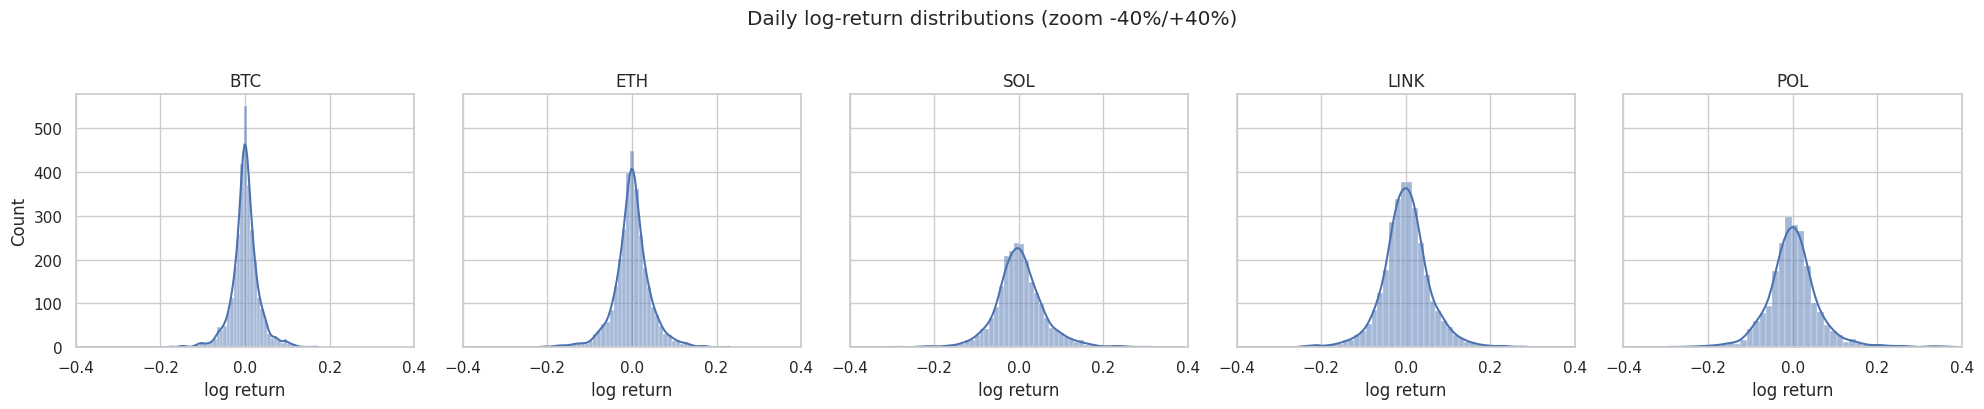

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, (sym, df) in zip(axes, panel.items()):
    sns.histplot(df["log_return"].dropna(), bins=80, kde=True, ax=ax)
    ax.set_title(f"{sym}")
    ax.set_xlabel("log return")
    ax.set_xlim(-0.4, 0.4)
plt.suptitle("Daily log-return distributions (zoom -40%/+40%)", y=1.02)
plt.tight_layout()


## Autocorrelazione: rendimenti vs |rendimenti|

`ACF(r) ≈ 0` + `ACF(|r|) > 0` = volatility clustering (mercato weak-form
efficient nei rendimenti, ma vol predicibile).


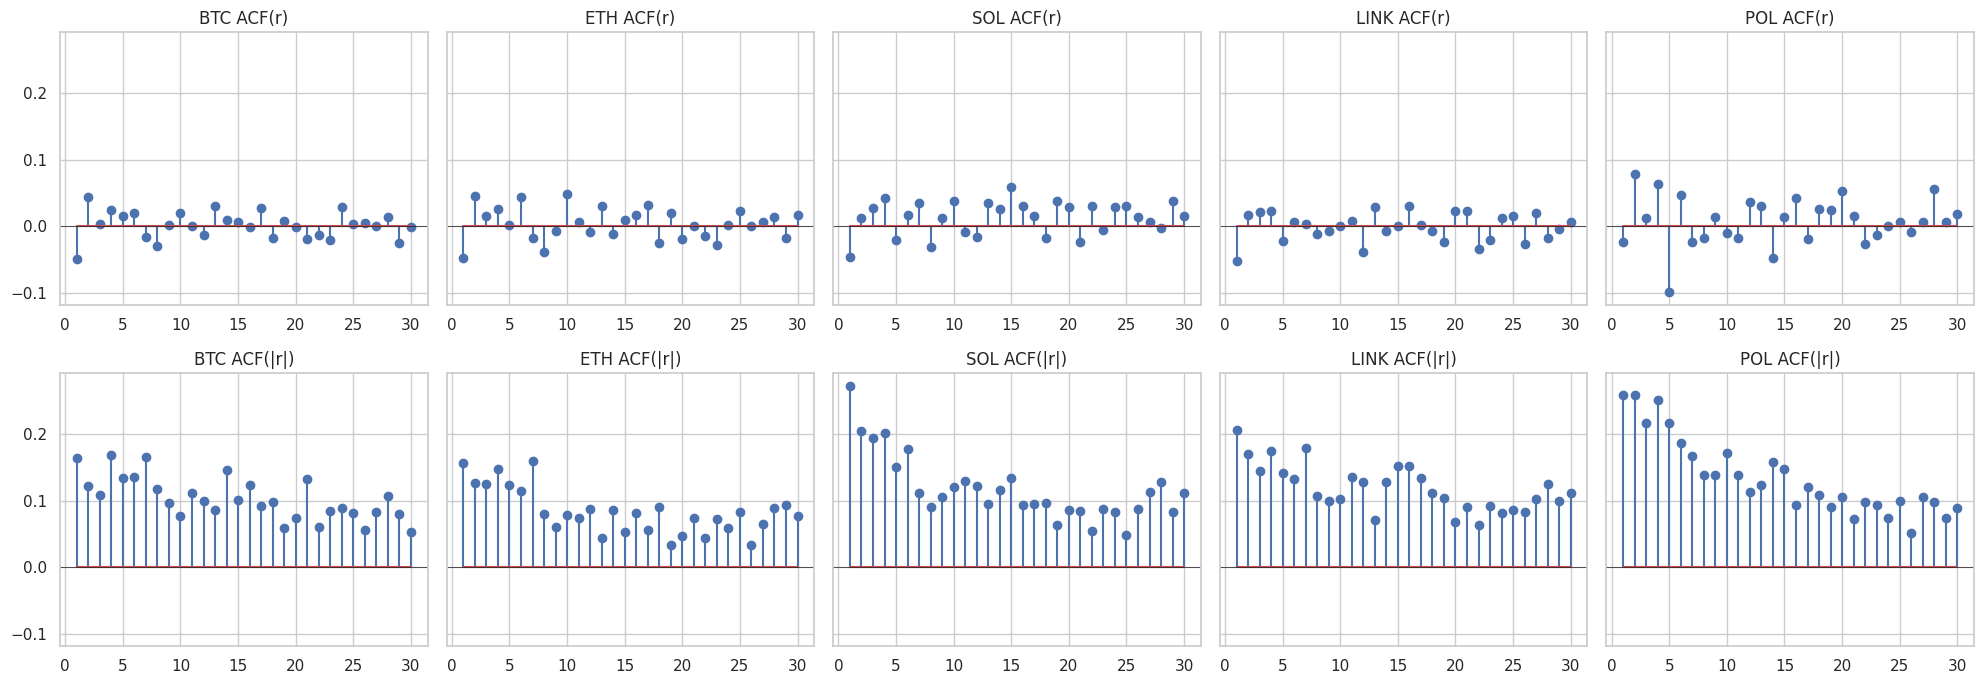

In [5]:
LAGS = list(range(1, 31))

fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=True)
for col, (sym, df) in enumerate(panel.items()):
    r = df["log_return"].dropna()
    axes[0, col].stem(LAGS, [r.autocorr(lag=k) for k in LAGS])
    axes[0, col].axhline(0, color="k", lw=0.5)
    axes[0, col].set_title(f"{sym} ACF(r)")
    axes[1, col].stem(LAGS, [r.abs().autocorr(lag=k) for k in LAGS])
    axes[1, col].axhline(0, color="k", lw=0.5)
    axes[1, col].set_title(f"{sym} ACF(|r|)")
plt.tight_layout()


In [6]:
# Quantitative ACF table (lags 1, 5, 10) for both r and |r|
acf_rows = []
for sym, df in panel.items():
    r = df["log_return"].dropna()
    abs_r = r.abs()
    acf_rows.append({
        "symbol": sym,
        "ACF(r) l1": r.autocorr(1),
        "ACF(r) l5": r.autocorr(5),
        "ACF(r) l10": r.autocorr(10),
        "ACF(|r|) l1": abs_r.autocorr(1),
        "ACF(|r|) l5": abs_r.autocorr(5),
        "ACF(|r|) l10": abs_r.autocorr(10),
    })
pd.DataFrame(acf_rows).set_index("symbol").round(3)


,ACF(r) l1,ACF(r) l5,ACF(r) l10,ACF(|r|) l1,ACF(|r|) l5,ACF(|r|) l10
symbol,,,,,,
BTC,-0.050,0.016,0.020,0.165,0.135,0.077
ETH,-0.048,0.003,0.048,0.157,0.125,0.079
SOL,-0.047,-0.020,0.038,0.273,0.151,0.121
LINK,-0.052,-0.022,-0.000,0.206,0.143,0.103
POL,-0.023,-0.099,-0.009,0.260,0.218,0.172


## Correlazione cross-asset

Quanto i Tier 1 si muovono insieme? Quanta diversificazione c'è dentro la
nostra universe? Calcolo Pearson sull'intersezione delle date comuni.


Common-dates window: 2020-04-11 -> 2025-03-24 (1809 rows)


,BTC,ETH,SOL,LINK,POL
BTC,1.000,0.809,0.533,0.655,0.603
ETH,0.809,1.000,0.608,0.751,0.681
SOL,0.533,0.608,1.000,0.565,0.531
LINK,0.655,0.751,0.565,1.000,0.660
POL,0.603,0.681,0.531,0.660,1.000


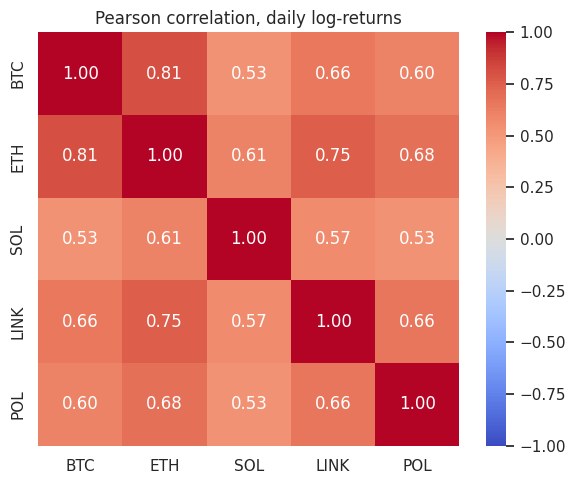

In [7]:
returns_panel = pd.DataFrame({sym: df["log_return"] for sym, df in panel.items()})
returns_panel = returns_panel.dropna(how="any")  # date comuni a tutti i 5
print(f"Common-dates window: {returns_panel.index.min().date()} -> {returns_panel.index.max().date()} ({len(returns_panel)} rows)")

corr = returns_panel.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation, daily log-returns")
plt.tight_layout()
corr.round(3)


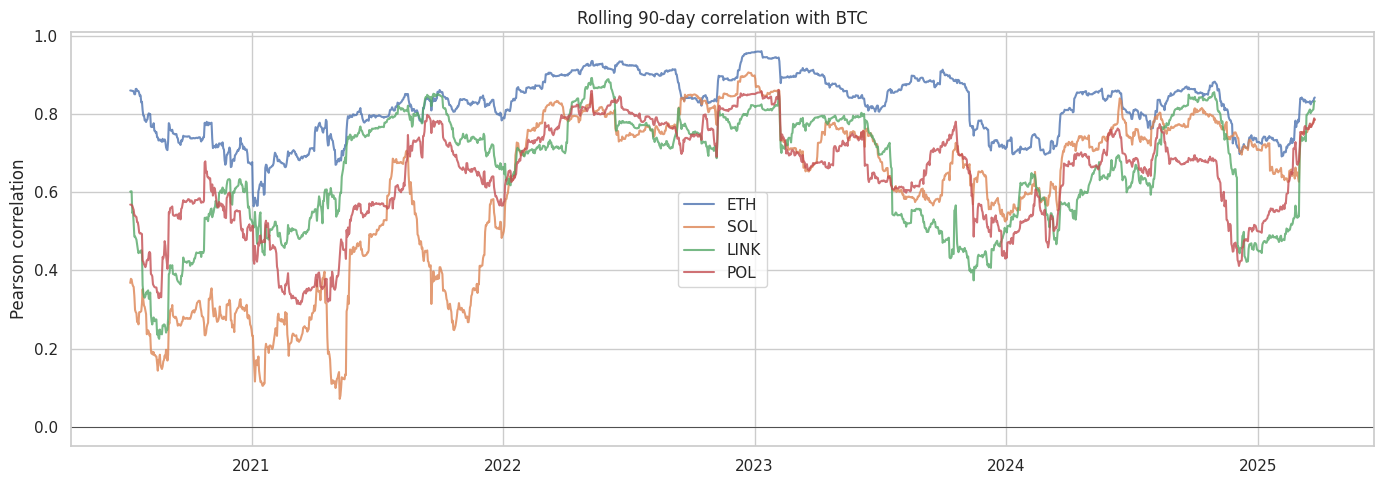

In [8]:
# Rolling 90-day correlation of each altcoin with BTC: are correlations stable?
WINDOW = 90
fig, ax = plt.subplots(figsize=(14, 5))
for sym in [s for s in TIER1_SYMBOLS if s != "BTC"]:
    rc = returns_panel[sym].rolling(WINDOW).corr(returns_panel["BTC"])
    ax.plot(rc.index, rc.values, label=sym, alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Rolling {WINDOW}-day correlation with BTC")
ax.set_ylabel("Pearson correlation")
ax.legend()
plt.tight_layout()


## Note per iterazioni successive

- Aggiungere context assets (SPX, NDX, DXY, GOLD) e calcolare correlazioni
  rolling crypto vs macro
- Identificare visivamente regimi (bull/bear/sideways) e marcare eventi
  noti (FTX collapse 2022-11, ETF approval 2024-01, halving 2024-04)
- Stagionalità: rendimenti per giorno della settimana, mese
- Test formali sulla normalità (Jarque-Bera, Anderson-Darling) — già
  visivamente respinta, ma utile averlo a livello statistico
- Volatility clustering: fit GARCH(1,1) come baseline per modello di
  varianza condizionata
